<a href="https://colab.research.google.com/github/yuliia-naumeniuk/global-retail-sales-analysis/blob/main/Global_Retail_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Data overview**

In [ ]:
# Connecting Google Drive

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Example of changing work folder

%cd /content/drive/MyDrive/PythonTask


/content/drive/MyDrive/PythonTask


In [ ]:
# Importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

In [ ]:
# Opening the ZIP file and viewing its contents

with zipfile.ZipFile("dataset.zip") as z:
    print(z.namelist())

['13. Final project/countries.csv', '13. Final project/products.csv', '13. Final project/events.csv']


In [ ]:
# Reading CSV files from the ZIP archive

with zipfile.ZipFile("dataset.zip") as z:
    events = pd.read_csv(z.open("13. Final project/events.csv"))
    products = pd.read_csv(z.open("13. Final project/products.csv"))
    countries = pd.read_csv(z.open("13. Final project/countries.csv"))

print(events.head())
print(products.head())
print(countries.head())

    Order ID Order Date   Ship Date Order Priority Country Code  Product ID  \
0  100640618  10/8/2014  10/18/2014              M          NOR        2103   
1  100983083  8/11/2016   8/11/2016              C          SRB        2103   
2  101025998  7/18/2014   8/11/2014              M          NaN        7940   
3  102230632  5/13/2017   6/13/2017              L          MNE        2455   
4  103435266  8/11/2012   9/18/2012              H          SRB        1270   

  Sales Channel  Units Sold  Unit Price  Unit Cost  
0        Online       650.0      205.70     117.11  
1       Offline      1993.0      205.70     117.11  
2        Online      4693.0      668.27     502.54  
3        Online      1171.0      109.28      35.84  
4       Offline      7648.0       47.45      31.79  
     id        item_type
0  2103           Cereal
1  7940        Household
2  2455          Clothes
3  1270        Beverages
4  8681  Office Supplies
             name alpha-2 alpha-3   region       sub-regi

***The "events.csv" table:***
*   *Order ID* - order identifier
*   *Order Date* - order date
*   *Ship Date* - shipment date
*   *Order Priority* - order priority
*   *Country Code* - 3-letter country code
*   *Product ID* - product identifier
*   *Sales Channel* - sales channel (*Online/Offline*)
*   *Units Sold* - number of units sold
*   *Unit Price* - price per unit
*   *Unit Cost* - cost per unit


***The "products.csv" table:***
*   *id* - product identifier
*   *item_type* - product category


***The "countries.csv" table:***
*   *name* - country name
*   *alpha-2* - 2-letter country code
*   *alpha-3* - 3-letter country code
*   *region* - region
*   *sub-region* - subregion

In [ ]:
# Descriptive statistics of the numerical columns in the "events" DataFrame

print(events.describe())

           Order ID   Product ID   Units Sold   Unit Price    Unit Cost
count  1.330000e+03  1330.000000  1328.000000  1330.000000  1330.000000
mean   5.412048e+08  5788.096241  4952.201807   264.893541   187.246812
std    2.573882e+08  2820.728878  2905.198996   217.323460   176.158873
min    1.006406e+08  1270.000000     2.000000     9.330000     6.920000
25%    3.190004e+08  3127.000000  2356.750000    81.730000    35.840000
50%    5.387164e+08  5988.000000  4962.000000   154.060000    97.440000
75%    7.544628e+08  8681.000000  7459.500000   437.200000   263.330000
max    9.998797e+08  8969.000000  9999.000000   668.270000   524.960000


# **2. Data cleaning**

In [ ]:
# Count of missing values in the "events" DataFrame

events.isna().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,82
Product ID,0
Sales Channel,0
Units Sold,2
Unit Price,0
Unit Cost,0


In [ ]:
# Proportion of missing values (%) in the "events" DataFrame

events.isna().sum() / events.shape[0] *100

,0
Order ID,0.000000
Order Date,0.000000
Ship Date,0.000000
Order Priority,0.000000
Country Code,6.165414
Product ID,0.000000
Sales Channel,0.000000
Units Sold,0.150376
Unit Price,0.000000
Unit Cost,0.000000


In [ ]:
# Imputing missing values in the "Country Code" column with "Unknown"

events["Country Code"] = events["Country Code"].fillna("Unknown")
events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,Unknown,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
# Imputing missing values in the "Units Sold" column with the mean

events["Units Sold"] = events["Units Sold"].fillna(events["Units Sold"].mean())
events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,Unknown,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


(EN)

* Missing values in the *"Country Code"* column were replaced with *"Unknown"* because this column is categorical and does not affect the results of calculations. In addition, missing data in this column does not mean that the whole row is incorrect.

* Missing values in the *"Units Sold"* column were replaced with the mean value because their percentage is small and does not affect the overall statistics or calculations.

(PL)

* Brakujące wartości w kolumnie *"Country Code"* zostały zastąpione wartością *"Unknown"*, ponieważ kolumna ta jest kategoryczna i nie wpływa na wyniki obliczeń. Dodatkowo brak danych w tej kolumnie nie oznacza, że cały wiersz jest niepoprawny.

* Brakujące wartości w kolumnie *"Units Sold"* zostały zastąpione wartością średnią, ponieważ ich procent jest niewielki i nie wpływa na ogólne statystyki ani obliczenia.

In [ ]:
# Count of missing values in the "products" DataFrame

products.isna().sum()

,0
id,0
item_type,0


In [ ]:
# Count of missing values in the "countries" DataFrame

countries.isna().sum()

,0
name,0
alpha-2,1
alpha-3,0
region,1
sub-region,1


In [ ]:
# Proportion of missing values (%) in the "countries" DataFrame

countries.isna().sum() / countries.shape[0] *100

,0
name,0.000000
alpha-2,0.401606
alpha-3,0.000000
region,0.401606
sub-region,0.401606


In [ ]:
# Removing rows with missing values in the "alpha-2", "region", and "sub-region" columns

countries = countries.dropna()
countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


(EN)

It can be seen that the percentage of missing values in the three columns *("alpha-2", "region", and "sub-region")* is the same and does not exceed 0.4%. This means that the amount of missing data is small and does not affect the overall statistics or calculations, so the rows containing missing values in these columns can be removed.

(PL)

Można zauważyć, że procent brakujących wartości w trzech kolumnach *("alpha-2", "region" oraz "sub-region")* jest taki sam i nie przekracza 0,4%. Oznacza to, że ilość brakujących danych jest niewielka i nie wpływa na ogólne statystyki ani obliczenia, dlatego można usunąć wiersze zawierające braki w tych kolumnach.

In [ ]:
# Structure of the "events" DataFrame. Verification of correct data type recognition

events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1330 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1330 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [ ]:
# Data type conversion in the columns

events["Order Date"] = pd.to_datetime(events["Order Date"])
events["Ship Date"] = pd.to_datetime(events["Ship Date"])
events["Units Sold"] = events["Units Sold"].astype("int64")

In [ ]:
# Verification of the structure of the "events" DataFrame

events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1330 non-null   int64         
 1   Order Date      1330 non-null   datetime64[ns]
 2   Ship Date       1330 non-null   datetime64[ns]
 3   Order Priority  1330 non-null   object        
 4   Country Code    1330 non-null   object        
 5   Product ID      1330 non-null   int64         
 6   Sales Channel   1330 non-null   object        
 7   Units Sold      1330 non-null   int64         
 8   Unit Price      1330 non-null   float64       
 9   Unit Cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(3), object(3)
memory usage: 104.0+ KB


In [ ]:
# Overview of the structure of the "products" DataFrame

products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In [ ]:
# Overview of the structure of the "countries" DataFrame

countries.info()

<class 'pandas.core.frame.DataFrame'>
Index: 247 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        247 non-null    object
 1   alpha-2     247 non-null    object
 2   alpha-3     247 non-null    object
 3   region      247 non-null    object
 4   sub-region  247 non-null    object
dtypes: object(5)
memory usage: 11.6+ KB


In [ ]:
# Verification of duplicate records in the "events" DataFrame

events.duplicated().sum()

np.int64(0)

In [ ]:
# Verification of duplicate records in the "products" DataFrame

products.duplicated().count()

np.int64(12)

In [ ]:
# Verification of duplicate records in the "countries" DataFrame

countries.duplicated().count()

np.int64(247)

# **3. Data analysis and visualization**

In [ ]:
# Merging three tables into one DataFrame

# "events" + "products" (Product Id = id)
df = events.merge(products, left_on="Product ID", right_on="id", how="left")

# "events" + "countries" (Country Code = alpha-3)
df = df.merge(countries, left_on="Country Code", right_on="alpha-3", how="left")

df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,id,item_type,name,alpha-2,alpha-3,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693,668.27,502.54,7940,Household,NaN,NaN,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe


In [ ]:
# Dropping unnecessary columns

df = df.drop(columns=["id", "alpha-2", "alpha-3"])
df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,item_type,name,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693,668.27,502.54,Household,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648,47.45,31.79,Beverages,Serbia,Europe,Southern Europe


In [ ]:
# Renaming columns

df = df.rename(columns={"item_type" : "product_category", "name" : "country", "sub-region" : "sub_region"})
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,product_category,country,region,sub_region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693,668.27,502.54,Household,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648,47.45,31.79,Beverages,Serbia,Europe,Southern Europe


## ***`Key performance indicators (KPIs)`***


In [ ]:
# Total orders

number_of_orders = df["order_id"].count()
print(f"Total number of orders: {number_of_orders}")

Total number of orders: 1330


In [ ]:
# Total product categories

number_of_categories = df["product_category"].nunique()
print(f"Number of categories: {number_of_categories}")

Number of categories: 12


In [ ]:
# Total countries

number_of_countries = df["country"].nunique()
print(f"Number of countries: {number_of_countries}")

Number of countries: 45


In [ ]:
# Total units sold by product category

units_sold_by_category = df.groupby("product_category")["units_sold"].sum().sort_values(ascending=False).reset_index()
print(units_sold_by_category)

   product_category  units_sold
0   Office Supplies      617641
1         Beverages      613133
2            Fruits      591672
3           Clothes      591385
4        Vegetables      582544
5         Baby Food      562706
6     Personal Care      562630
7              Meat      535332
8         Cosmetics      533291
9            Snacks      490160
10           Cereal      465685
11        Household      440249


In [ ]:
# Sales channel distribution

sales_channels = df["sales_channel"].value_counts()
print(sales_channels)

sales_channel
Offline    667
Online     660
online       3
Name: count, dtype: int64


In [ ]:
# Normalizing text in the "sales_channel" column

df["sales_channel"] = df["sales_channel"].str.strip().str.capitalize()
df["sales_channel"].unique()

array(['Online', 'Offline'], dtype=object)

In [ ]:
# Sales channel distribution check

sales_channels = df["sales_channel"].value_counts()
print(f"Sales channels: {sales_channels}")

Sales channels: sales_channel
Offline    667
Online     663
Name: count, dtype: int64


## ***`Analysis of sales performance`***

In [ ]:
# Total revenue

df["revenue"] = df["unit_price"] * df["units_sold"]
total_revenue = df["revenue"].sum()
print(f"Total revenue: {total_revenue}")

Total revenue: 1704623334.4499998


In [ ]:
# Total revenue by product category

revenue_by_category = df.groupby("product_category")["revenue"].sum().sort_values(ascending=False).reset_index()
print(revenue_by_category)

   product_category       revenue
0   Office Supplies  4.022140e+08
1         Household  2.942052e+08
2         Cosmetics  2.331548e+08
3              Meat  2.258512e+08
4         Baby Food  1.436476e+08
5            Cereal  9.579140e+07
6        Vegetables  8.974673e+07
7            Snacks  7.478861e+07
8           Clothes  6.462655e+07
9     Personal Care  4.598375e+07
10        Beverages  2.909316e+07
11           Fruits  5.520300e+06


In [ ]:
# Total costs

df["total_cost"] = df["unit_cost"] * df["units_sold"]
total_cost = df["total_cost"].sum()
print(f"Total cost: {total_cost}")

Total cost: 1202781523.9299998


In [ ]:
# Total costs by product category

cost_by_category = df.groupby("product_category")["total_cost"].sum().sort_values(ascending=False).reset_index()
print(cost_by_category)

   product_category    total_cost
0   Office Supplies  3.242368e+08
1         Household  2.212427e+08
2              Meat  1.952302e+08
3         Cosmetics  1.404315e+08
4         Baby Food  8.970659e+07
5            Cereal  5.453637e+07
6        Vegetables  5.297073e+07
7            Snacks  4.776119e+07
8     Personal Care  3.188424e+07
9           Clothes  2.119524e+07
10        Beverages  1.949150e+07
11           Fruits  4.094370e+06


In [ ]:
# Total profit

df["profit"] = (df["unit_price"] - df["unit_cost"]) * df["units_sold"]
total_profit = df["profit"].sum()
print(f"Total profit: {total_profit}")

Total profit: 501841810.52


In [ ]:
# Total profit by product category

profit_by_category = df.groupby("product_category")["profit"].sum().sort_values(ascending=False).reset_index()
print(profit_by_category)

   product_category       profit
0         Cosmetics  92723306.17
1   Office Supplies  77977176.25
2         Household  72962466.77
3         Baby Food  53940997.16
4           Clothes  43431314.40
5            Cereal  41255034.15
6        Vegetables  36776002.72
7              Meat  30620990.40
8            Snacks  27027422.40
9     Personal Care  14099507.80
10        Beverages   9601662.78
11           Fruits   1425929.52


In [ ]:
# Product category distribution (frequency)

df["product_category"].value_counts()

,count
product_category,
Office Supplies,123
Beverages,121
Personal Care,115
Cosmetics,114
Vegetables,114
Baby Food,112
Fruits,112
Meat,111
Clothes,105


In [ ]:
# Product category popularity (units sold)

product_popularity = df.groupby("product_category")["units_sold"].sum().sort_values(ascending=False).reset_index()
print(product_popularity)

   product_category  units_sold
0   Office Supplies      617641
1         Beverages      613133
2            Fruits      591672
3           Clothes      591385
4        Vegetables      582544
5         Baby Food      562706
6     Personal Care      562630
7              Meat      535332
8         Cosmetics      533291
9            Snacks      490160
10           Cereal      465685
11        Household      440249


/tmp/ipython-input-544/3024887985.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_popularity, x="product_category", y="units_sold", palette=colors, errorbar=("ci", False))


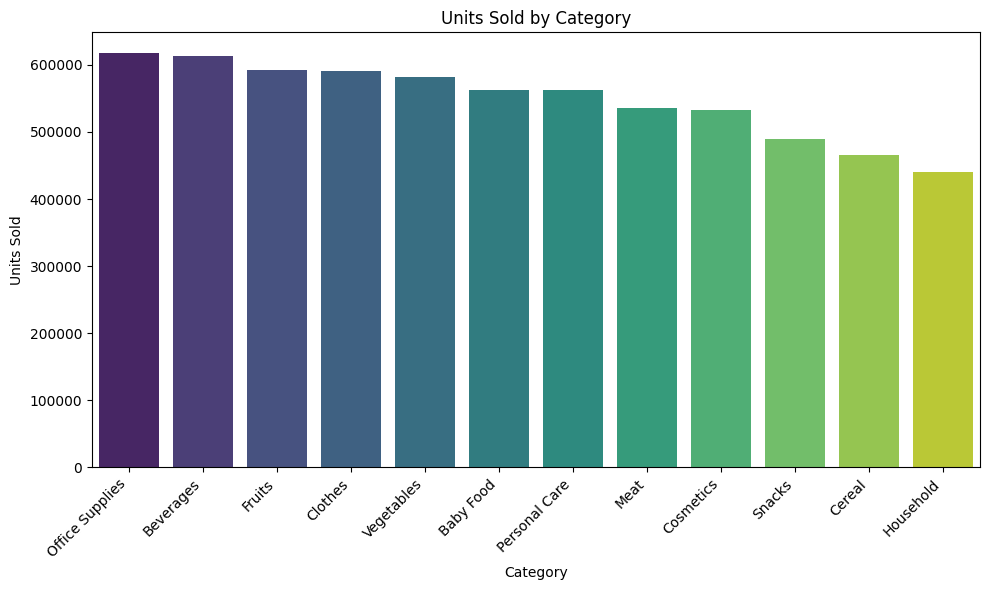

In [ ]:
# Product category popularity visualization

colors = sns.color_palette("viridis", len(product_popularity))

plt.figure(figsize=(10,6))

sns.barplot(data=product_popularity, x="product_category", y="units_sold", palette=colors, errorbar=("ci", False))
plt.title("Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

(EN)

***Number of units sold by product category:***

* The highest number of units was sold in the categories *Office Supplies*, *Beverages*, *Fruits*, and *Clothes*.

* The lowest number of units was sold in the categories *Snacks*, *Cereal*, and *Household*.

(PL)

***Liczba sprzedanych jednostek w podziale na kategorie produktów:***

* Najwięcej jednostek sprzedano w kategoriach *Office Supplies*, *Beverages*, *Fruits* oraz *Clothes*.

* Najmniej sprzedano w kategoriach *Snacks*, *Cereal* oraz *Household*.


/tmp/ipython-input-544/1513035029.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_category, x="product_category", y="revenue", palette=colors, errorbar=("ci", False))


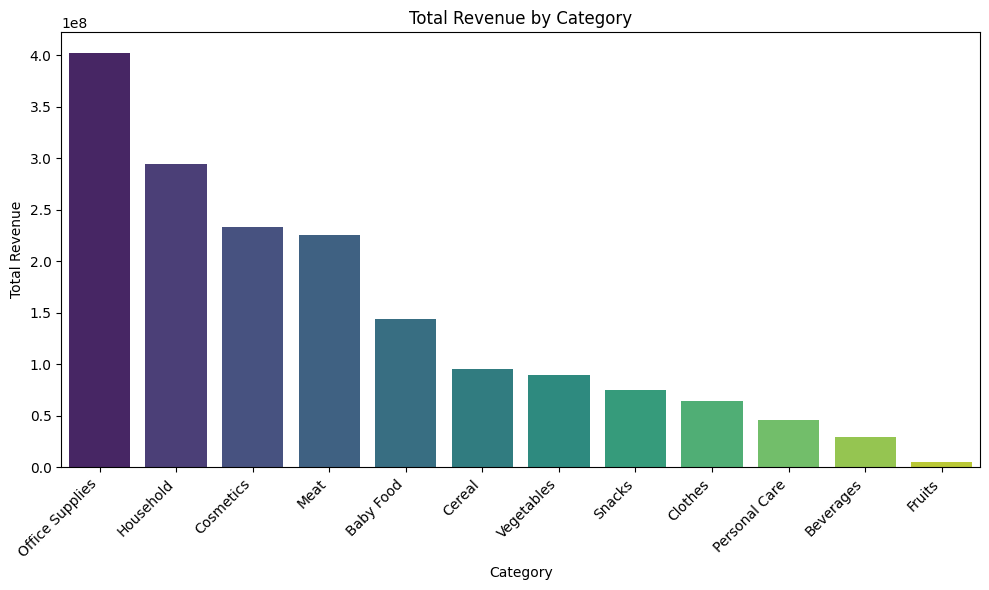

In [ ]:
# Visualizing total revenue by product category

colors = sns.color_palette("viridis", len(revenue_by_category))

plt.figure(figsize=(10,6))

sns.barplot(data=revenue_by_category, x="product_category", y="revenue", palette=colors, errorbar=("ci", False))
plt.title("Total Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

(EN)

***Total revenue by product category:***

* The leading category in terms of revenue is *Office Supplies*.

* Significant revenue is also generated by the categories *Household*, *Cosmetics*, and *Meat*.

* The lowest revenue is observed in the categories *Beverages* and *Fruits*.

(PL)

***Całkowity dochód w podziale na kategorie produktów:***

* Liderem pod względem dochodu jest kategoria *Office Supplies*.

* Znaczący dochód generują również kategorie *Household*, *Cosmetics* oraz *Meat*.

* Najniższy dochód odnotowano w kategoriach *Beverages* oraz *Fruits*.

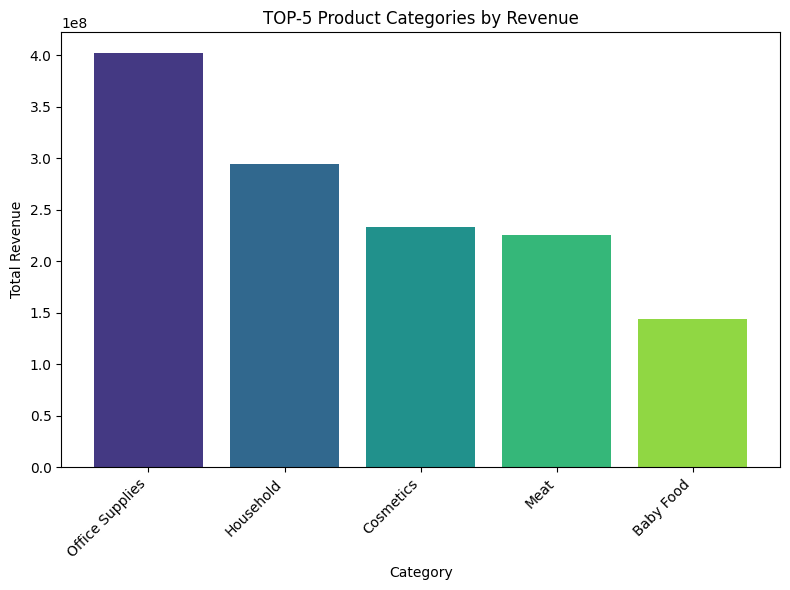

In [ ]:
# Visualizing the top 5 product categories by total revenue

top_categories = df.groupby("product_category")["revenue"].sum().nlargest(5)

colors = sns.color_palette("viridis", len(top_categories))

plt.figure(figsize=(8, 6))
plt.bar(top_categories.index, top_categories.values, color=colors)
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.title("TOP-5 Product Categories by Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipython-input-544/3275498032.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cost_by_category, x="product_category", y="total_cost", palette=colors, errorbar=("ci", False))
/tmp/ipython-input-544/3275498032.py:6: UserWarning: 
The palette list has fewer values (5) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=cost_by_category, x="product_category", y="total_cost", palette=colors, errorbar=("ci", False))


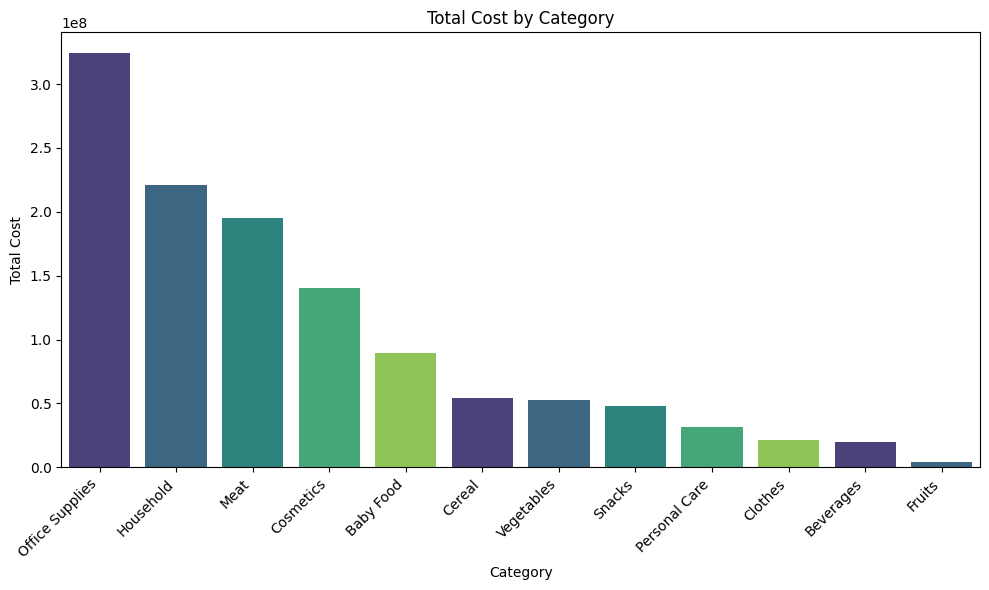

In [ ]:
# Visualizing total costs by product category

сolors = sns.color_palette("viridis", len(cost_by_category))

plt.figure(figsize=(10,6))
sns.barplot(data=cost_by_category, x="product_category", y="total_cost", palette=colors, errorbar=("ci", False))
plt.title("Total Cost by Category")
plt.xlabel("Category")
plt.ylabel("Total Cost")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

(EN)

***Total costs by product category:***

* The highest costs are observed in the *Office Supplies* category.

* Significant costs are also noted in the *Household* and *Meat* categories.

* The lowest costs are observed in the *Fruits* category.

(PL)

***Całkowite koszty w podziale na kategorie produktów:***

* Najwyższe koszty odnotowano w kategorii *Office Supplies*.

* Znaczące koszty występują również w kategoriach *Household* oraz *Meat*.

* Najniższe koszty odnotowano w kategorii *Fruits*.

/tmp/ipython-input-544/2113420313.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=profit_by_category, x="product_category", y="profit", palette=colors, errorbar=("ci", False))
/tmp/ipython-input-544/2113420313.py:6: UserWarning: 
The palette list has fewer values (5) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=profit_by_category, x="product_category", y="profit", palette=colors, errorbar=("ci", False))


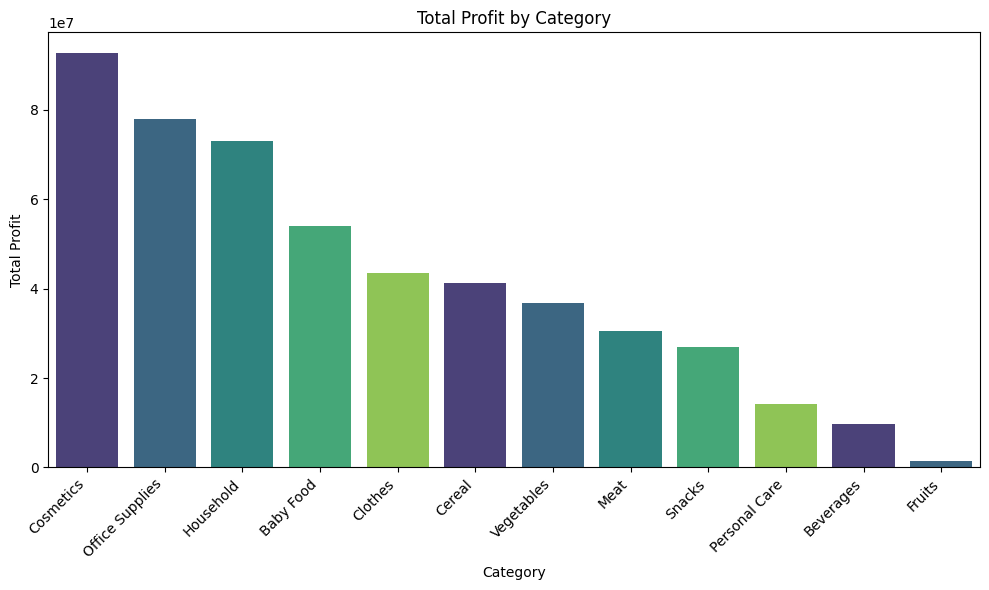

In [ ]:
# Visualizing total profit by product category

сolors = sns.color_palette("viridis", len(profit_by_category))

plt.figure(figsize=(10,6))
sns.barplot(data=profit_by_category, x="product_category", y="profit", palette=colors, errorbar=("ci", False))
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

(EN)

***Total profit by product category:***

* The most profitable categories are *Cosmetics*, *Office Supplies*, and *Household*.

* The least profitable categories are *Personal Care*, *Beverages*, and *Fruits*.

(PL)

***Całkowity zysk w podziale na kategorie produktów:***

* Najbardziej dochodowe kategorie to *Cosmetics*, *Office Supplies* oraz *Household*.

* Najmniej dochodowe to *Personal Care*, *Beverages* oraz *Fruits*.

In [ ]:
# Visualizing total revenue by country (map)

import plotly.express as px

revenue_map = df.groupby(["country", "country_code"])["revenue"].sum().reset_index()

map = px.choropleth(revenue_map, locations="country_code", color="revenue", hover_name="country", color_continuous_scale="Deep", projection="natural earth")

map.show()


In [ ]:
# Visualizing total profit by country (map)

profit_map = df.groupby(["country", "country_code"])["profit"].sum().reset_index()

map = px.choropleth(profit_map, locations="country_code", color="profit", hover_name="country", color_continuous_scale="Deep", projection="natural earth")

map.show()

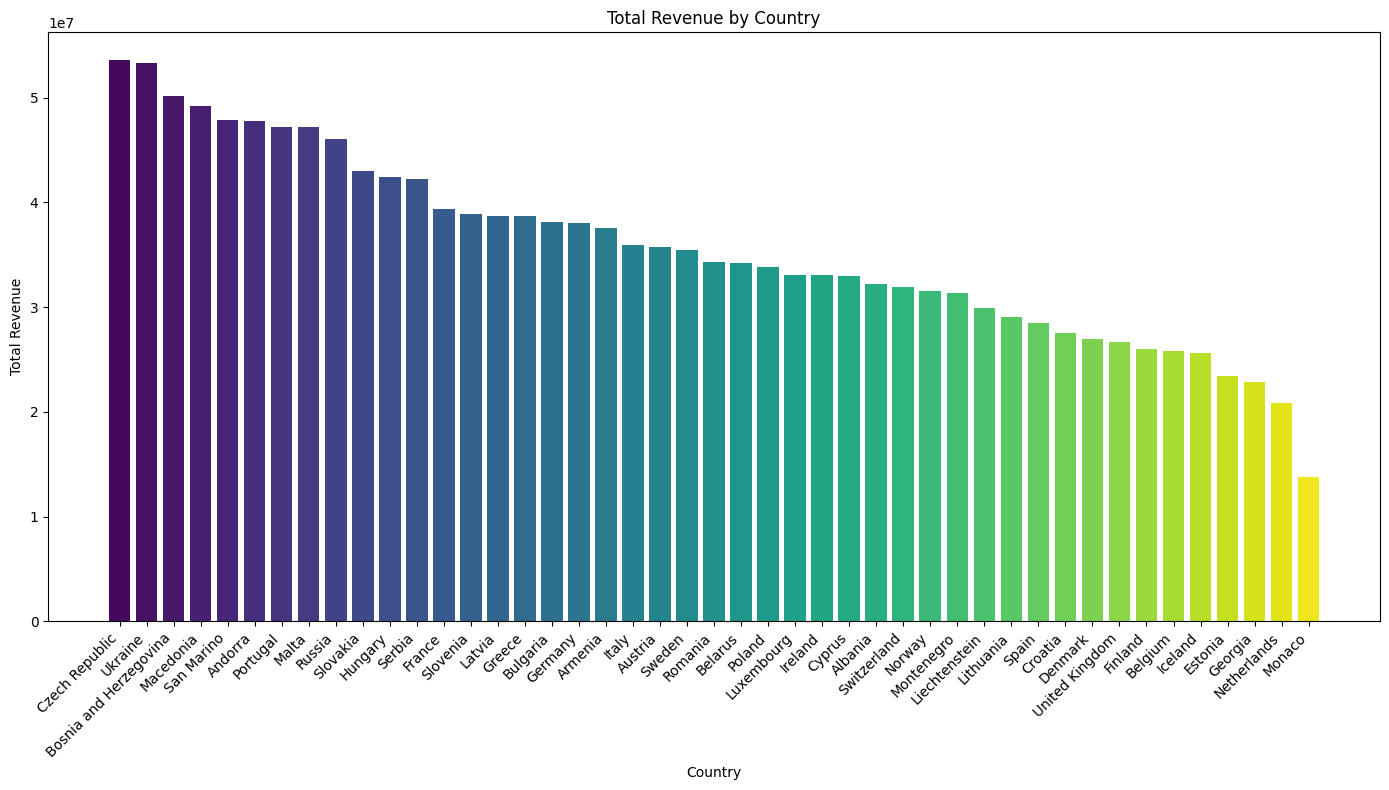

In [ ]:
пні питання # Visualizing total revenue by country (histogram)

revenue_by_country = df.groupby("country")["revenue"].sum().sort_values(ascending=False)

colors = sns.color_palette("viridis", len(revenue_by_country))

plt.figure(figsize=(14, 8))
plt.bar(revenue_by_country.index, revenue_by_country, color=colors)
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Country")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

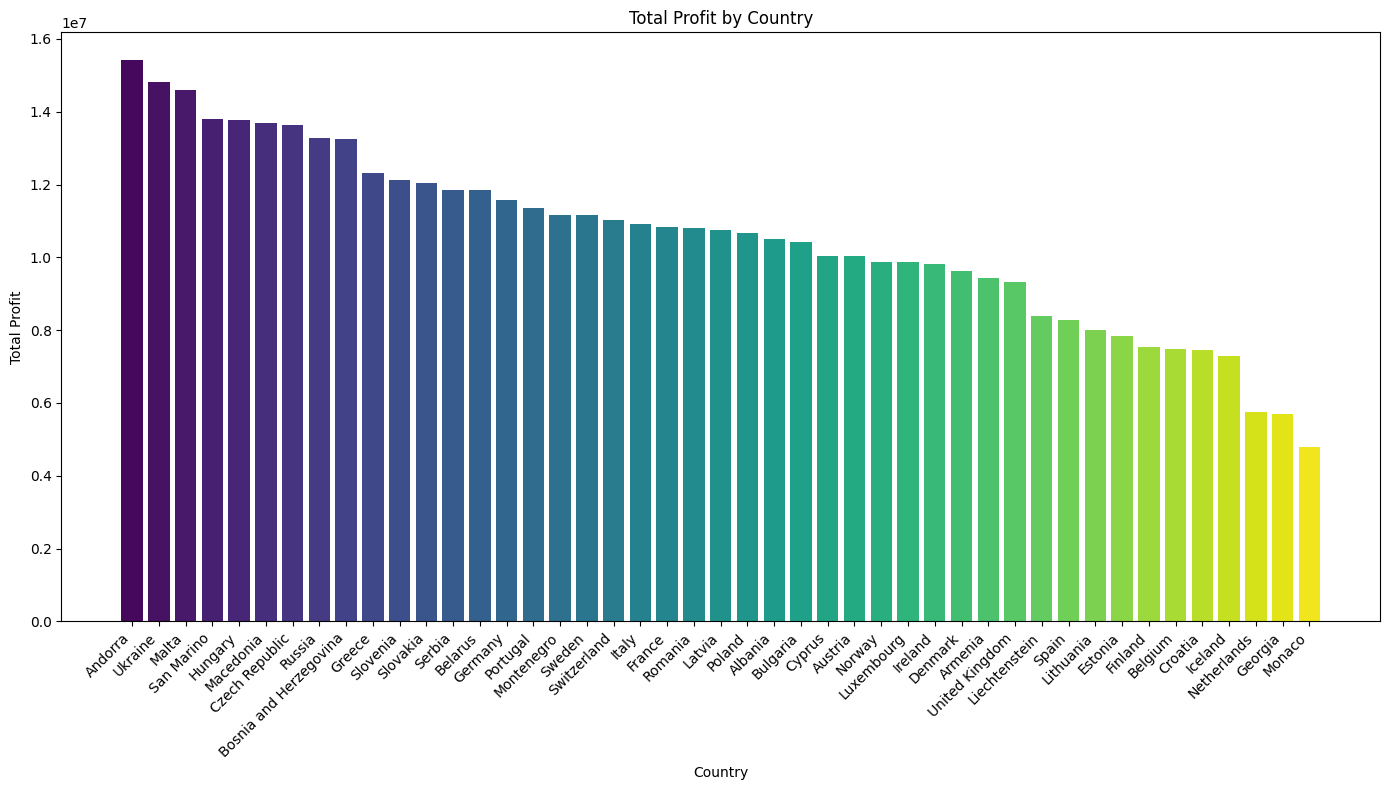

In [ ]:

# Visualizing total profit by country (histogram)

profit_by_country = df.groupby("country")["profit"].sum().sort_values(ascending=False)

colors = sns.color_palette("viridis", len(profit_by_country))

plt.figure(figsize=(14, 8))
plt.bar(profit_by_country.index, profit_by_country, color=colors)
plt.xlabel("Country")
plt.ylabel("Total Profit")
plt.title("Total Profit by Country")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

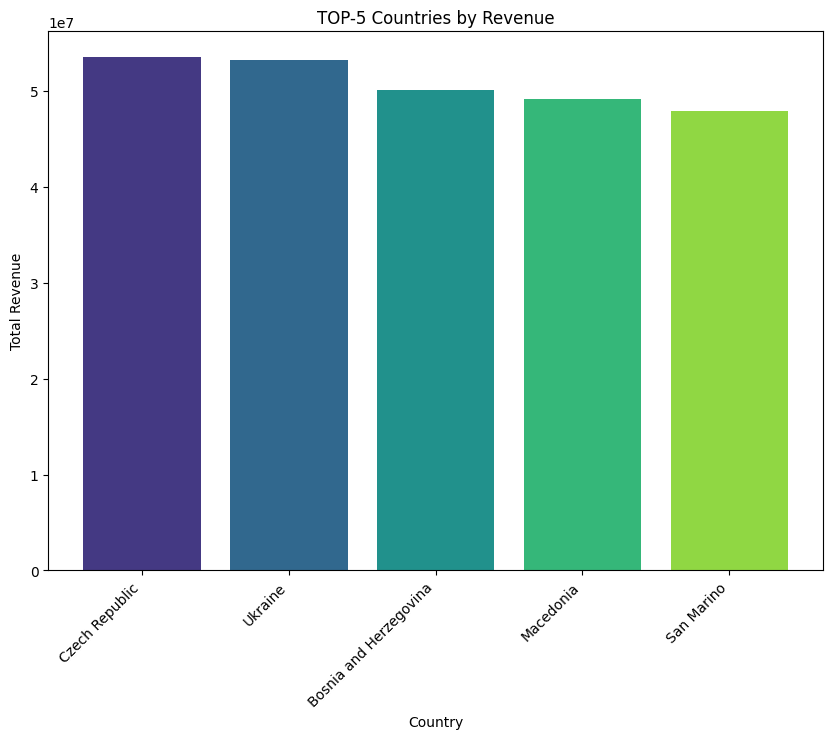

In [ ]:
# Visualizing the top 5 countries by total revenue

top_countries_by_revenue = df.groupby("country")["revenue"].sum().nlargest(5)

colors = sns.color_palette("viridis", len(top_countries_by_revenue))

plt.figure(figsize=(10, 7))

plt.bar(top_countries_by_revenue.index, top_countries_by_revenue, color=colors)
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.title("TOP-5 Countries by Revenue")
plt.xticks(rotation=45, ha="right")
plt.show()

(EN)

***Top 5 countries by revenue:***

1. Czechia
2. Ukraine
3. Bosnia and Herzegovina
4. Macedonia
5. San Marino

(PL)

***Top 5 krajów pod względem dochodu:***

1. Czechy
2. Ukraina
3. Bośnia i Hercegowina
4. Macedonia
5. San Marino

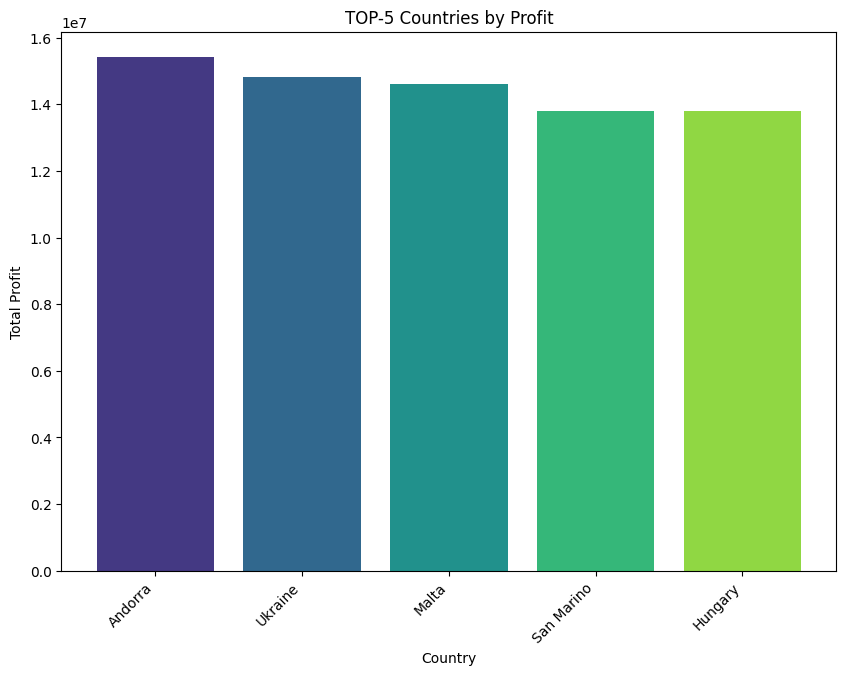

In [ ]:
# Visualizing the top 5 countries by total profit

top_countries_by_profit = df.groupby("country")["profit"].sum().nlargest(5)

colors = sns.color_palette("viridis", len(top_countries_by_profit))

plt.figure(figsize=(10, 7))
plt.bar(top_countries_by_profit.index, top_countries_by_profit, color=colors)
plt.xlabel("Country")
plt.ylabel("Total Profit")
plt.title("TOP-5 Countries by Profit")
plt.xticks(rotation=45, ha="right")
plt.show()

(EN)

***Top 5 countries by profit:***

1. Andorra
2. Ukraine
3. Malta
4. San Marino
5. Hungary

(PL)

***Top 5 krajów pod względem zysku:***

1. Andora
2. Ukraina
3. Malta
4. San Marino
5. Węgry

/tmp/ipython-input-544/2246225109.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




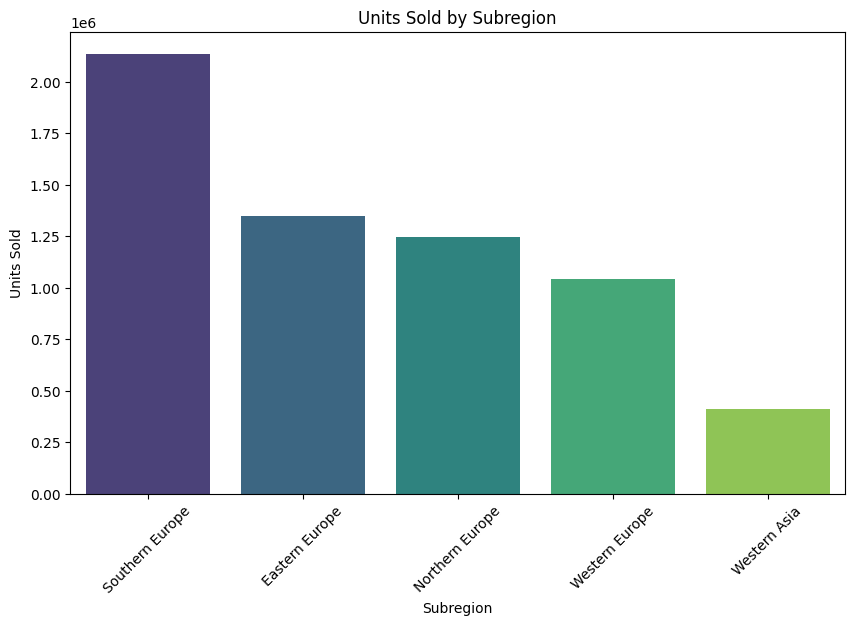

In [ ]:
# Visualizing total units sold by subregion

units_sold_by_subregion = df.groupby("sub_region")["units_sold"].sum().sort_values(ascending=False).reset_index()

colors = sns.color_palette("viridis", len(units_sold_by_subregion))

plt.figure(figsize=(10,6))
sns.barplot(data=units_sold_by_subregion, x="sub_region", y="units_sold", palette = colors, errorbar=("ci", False),)
plt.title("Units Sold by Subregion")
plt.xlabel("Subregion")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

(EN)

***Total number of units sold by subregion:***

* *Southern Europe* is the leading subregion in terms of the number of units sold.

* Significantly fewer units are sold in the following subregions: *Eastern Europe*, *Northern Europe*, and *Western Europe*.

* The lowest number of units sold is observed in *Western Asia*.

(PL)

***Całkowita liczba sprzedanych jednostek w podziale na subregiony:***

* Liderem pod względem liczby sprzedanych jednostek jest *Europa Południowa*.

* Znacznie mniej towarów sprzedaje się w następujących subregionach: *Europa Wschodnia*, *Europa Północna* oraz *Europa Zachodnia*.

* Najmniejszą liczbę sprzedanych jednostek odnotowano w *Azji Zachodniej*.


/tmp/ipython-input-544/2369757772.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




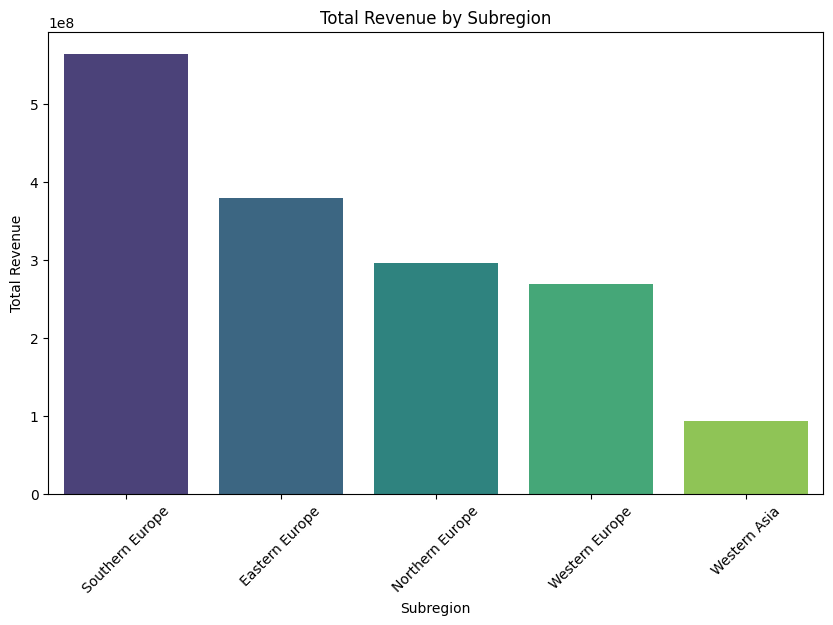

In [ ]:
# Visualizing total revenue by subregion

revenue_by_subregion = df.groupby("sub_region")["revenue"].sum().sort_values(ascending=False).reset_index()

colors = sns.color_palette("viridis", len(revenue_by_subregion))

plt.figure(figsize=(10,6))
sns.barplot(data=revenue_by_subregion, x="sub_region", y="revenue", palette=colors, errorbar=("ci", False),)
plt.title("Total Revenue by Subregion")
plt.xlabel("Subregion")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-544/74553445.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




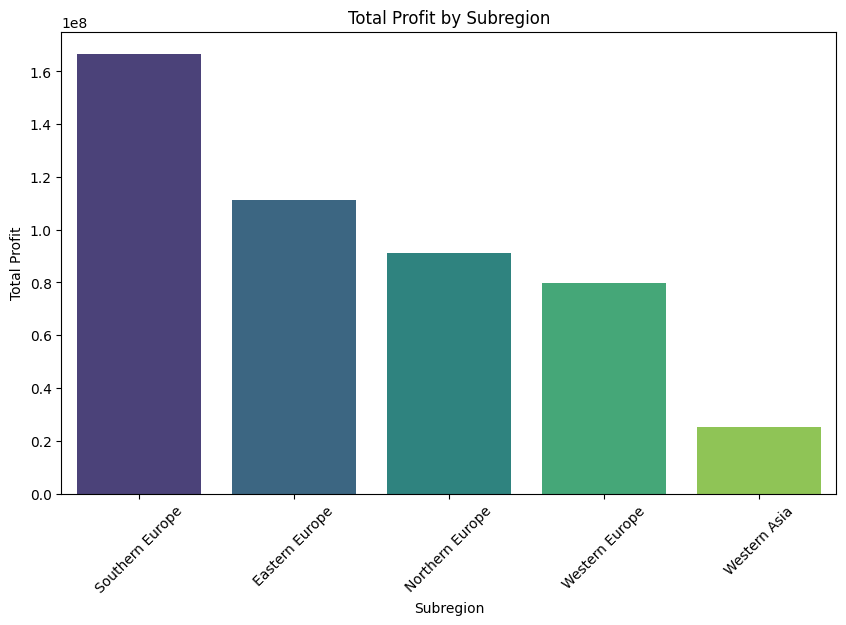

In [ ]:
# Visualizing total profit by subregion

profit_by_subregion = df.groupby("sub_region")["profit"].sum().sort_values(ascending=False).reset_index()

colors = sns.color_palette("viridis", len(profit_by_subregion))

plt.figure(figsize=(10,6))
sns.barplot(data=profit_by_subregion, x="sub_region", y="profit", palette=colors, errorbar=("ci", False),)
plt.title("Total Profit by Subregion")
plt.xlabel("Subregion")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.show()

(EN)

***Total revenue and profit by subregion:***

* Similarly to the number of units sold, *Southern Europe* remains the leading subregion in terms of both revenue and profit.

* Significantly lower but moderate results are observed in *Eastern Europe*, *Northern Europe*, and *Western Europe*.

* The lowest figures remain in *Western Asia*.

(PL)

***Całkowity dochód i zysk w podziale na subregiony:***

* Podobnie jak w przypadku liczby sprzedanych jednostek, *Europa Południowa* pozostaje liderem pod względem zarówno dochodu, jak i zysku.

* Znacznie niższe, lecz umiarkowane wyniki odnotowuje się w *Europie Wschodniej*, *Północnej* oraz *Zachodniej*.

* Najniższe wartości utrzymują się w *Azji Zachodniej*.




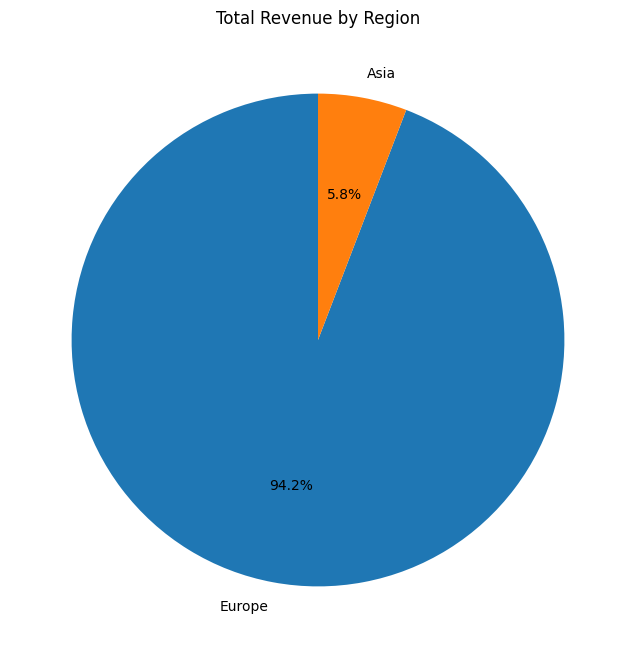

In [ ]:
# Visualizing total revenue by region

revenue_by_region = df.groupby("region")["revenue"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8,8))
plt.pie(revenue_by_region["revenue"], labels=revenue_by_region["region"], autopct="%1.1f%%", startangle=90)
plt.title("Total Revenue by Region")
plt.show()

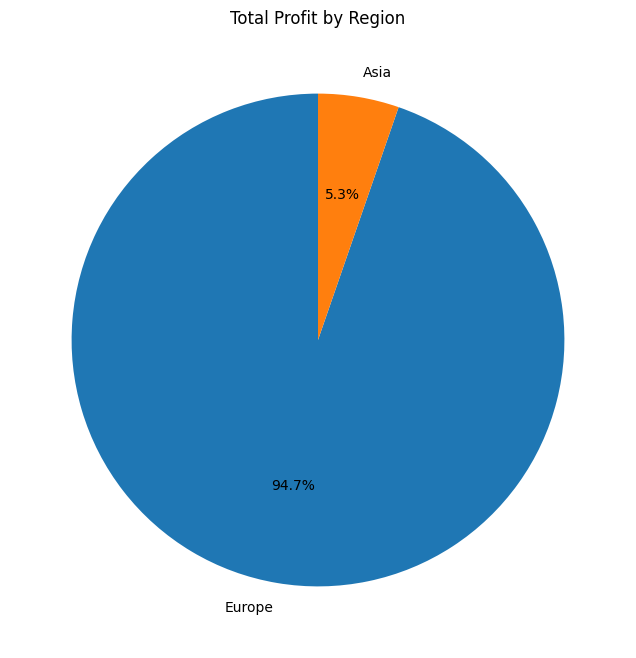

In [ ]:
# Visualizing total profit by region

profit_by_region = df.groupby("region")["profit"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8,8))
plt.pie(profit_by_region["profit"], labels=profit_by_region["region"], autopct="%1.1f%%", startangle=90)
plt.title("Total Profit by Region")
plt.show()

(EN)

Europe is the clear leader by region because the largest number of countries purchasing the company’s products are located there.

(PL)

Europa jest wyraźnym liderem, ponieważ największa liczba krajów kupujących produkty firmy znajduje się w tym regionie.

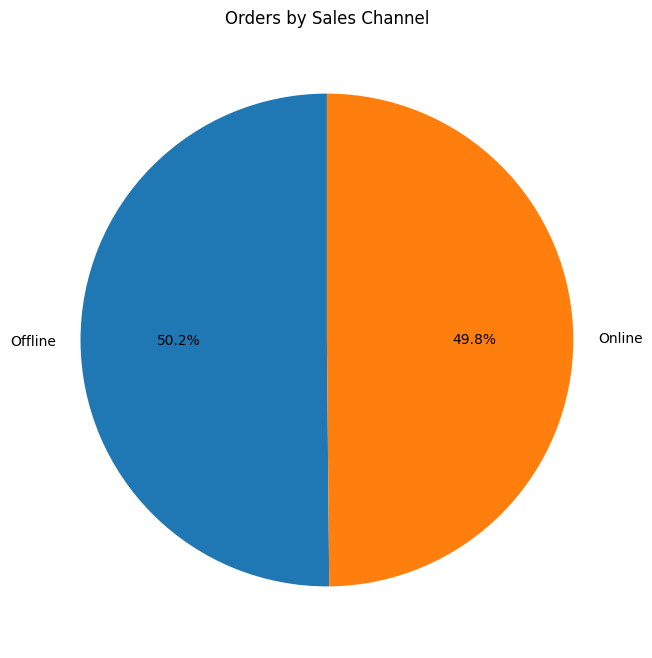

In [ ]:
# Visualizing the total number of orders by sales channel

orders_by_channels = df.groupby("sales_channel")["order_id"].count().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8,8))
plt.pie(orders_by_channels["order_id"], labels=orders_by_channels["sales_channel"], autopct="%1.1f%%", startangle=90)
plt.title("Orders by Sales Channel")
plt.show()

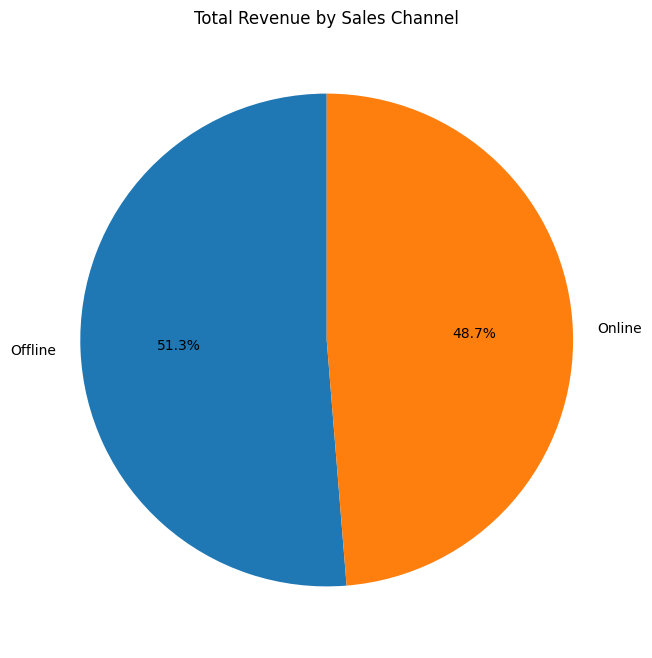

In [ ]:
# Visualizing total revenue by sales channel

revenue_by_channels = df.groupby("sales_channel")["revenue"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8,8))
plt.pie(revenue_by_channels["revenue"], labels=revenue_by_channels["sales_channel"], autopct="%1.1f%%", startangle=90)
plt.title("Total Revenue by Sales Channel")
plt.show()

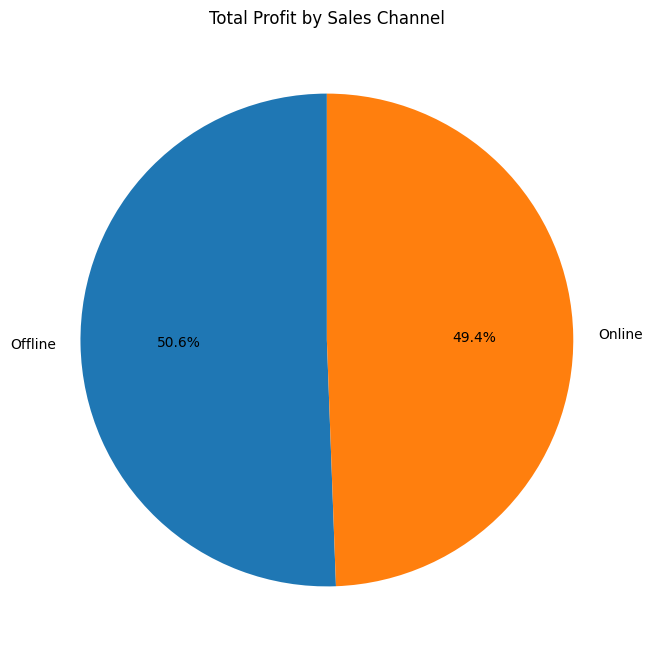

In [ ]:
# Visualizing total profit by sales channel

profit_by_channels = df.groupby("sales_channel")["profit"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8,8))
plt.pie(profit_by_channels["profit"], labels=profit_by_channels["sales_channel"], autopct="%1.1f%%", startangle=90)
plt.title("Total Profit by Sales Channel")
plt.show()

(EN)

The overall indicators *(Units Sold, Revenue, and Profit)* are quite similar across sales channels, and no significant differences are observed.

This suggests that the company’s customers equally prefer both *Offline* purchases and *Online* shopping.

(PL)

Ogólne wskaźniki *(Units Sold, Revenue oraz Profit)* są dość podobne w podziale na kanały sprzedaży i nie obserwuje się istotnych różnic.

Oznacza to, że klienci firmy w równym stopniu preferują zarówno zakupy stacjonarne *(Offline)*, jak i internetowe *(Online)*.

In [ ]:
# Total sales by sales channel and order date (double aggregation)

time_series_data = df.groupby(["sales_channel", "order_date"])["units_sold"].sum().reset_index()
time_series_data.head()


,sales_channel,order_date,units_sold
0,Offline,2010-01-01,9367
1,Offline,2010-01-06,2979
2,Offline,2010-01-11,6238
3,Offline,2010-01-12,15270
4,Offline,2010-01-13,1255


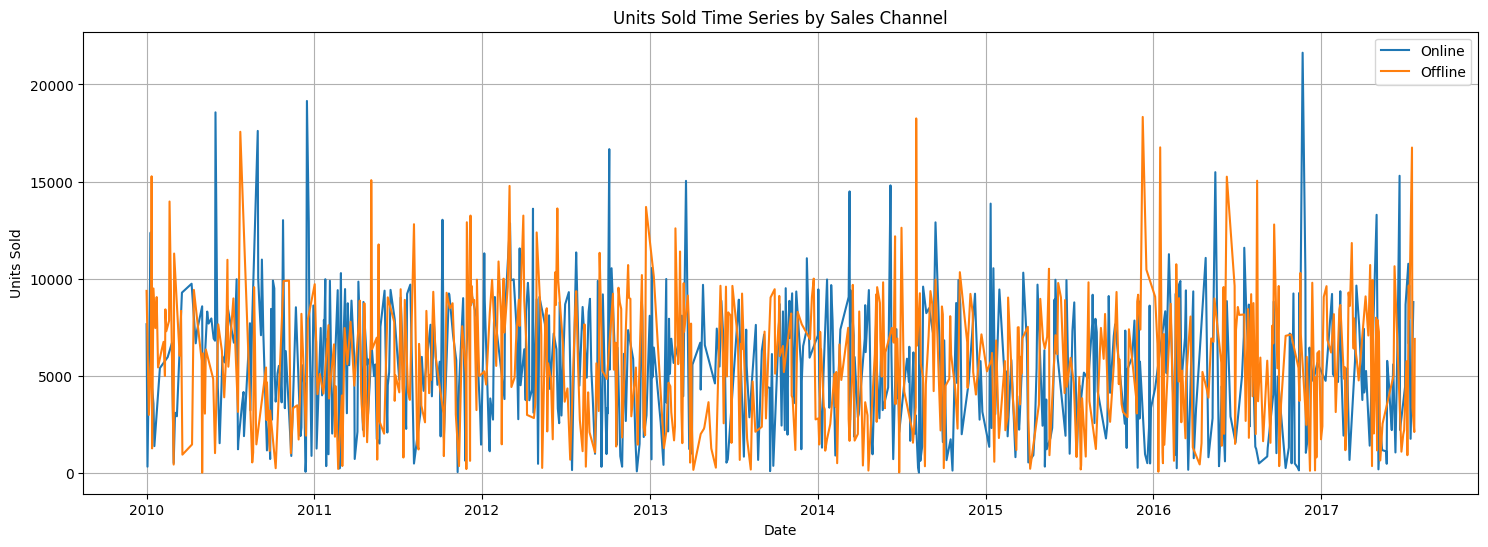

In [ ]:
# Visualizing Online and Offline sales trends

sales_channels = df["sales_channel"].unique()

plt.figure(figsize=(18,6))
for channel in sales_channels:
  channel_data = time_series_data[time_series_data["sales_channel"] == channel]
  plt.plot(channel_data["order_date"], channel_data["units_sold"], label=channel)

plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.title("Units Sold Time Series by Sales Channel")
plt.legend()
plt.grid(True)
plt.show()

(EN)

It can be observed from the chart that *Online* and *Offline* sales volumes are quite similar and fluctuate within the same range.

No clear patterns or seasonality can be identified. Sudden spikes may be related to large one-time purchases.

Overall, the level of demand remains stable throughout the entire period.

(PL)

Na wykresie można zauważyć, że wolumen sprzedaży *Online* i *Offline* jest dość podobny i waha się w tym samym zakresie.

Nie można zaobserwować wyraźnych zależności ani sezonowości. Nagłe wzrosty mogą być związane z dużymi jednorazowymi zakupami.

Ogólnie poziom popytu pozostaje stabilny w całym analizowanym okresie.

## ***`Order-to-shipment time analysis`***

In [ ]:
# Order-to-shipment time

shipping_time = df["ship_date"] - df["order_date"]
shipping_time = shipping_time.dt.days
df["shipping_time"] = shipping_time
df = df[df["shipping_time"] >= 0]
print(df["shipping_time"])


0       10
1        0
2       24
3       31
4       38
        ..
1325     3
1326    28
1327     2
1328    18
1329    36
Name: shipping_time, Length: 1330, dtype: int64


/tmp/ipython-input-544/2775529033.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




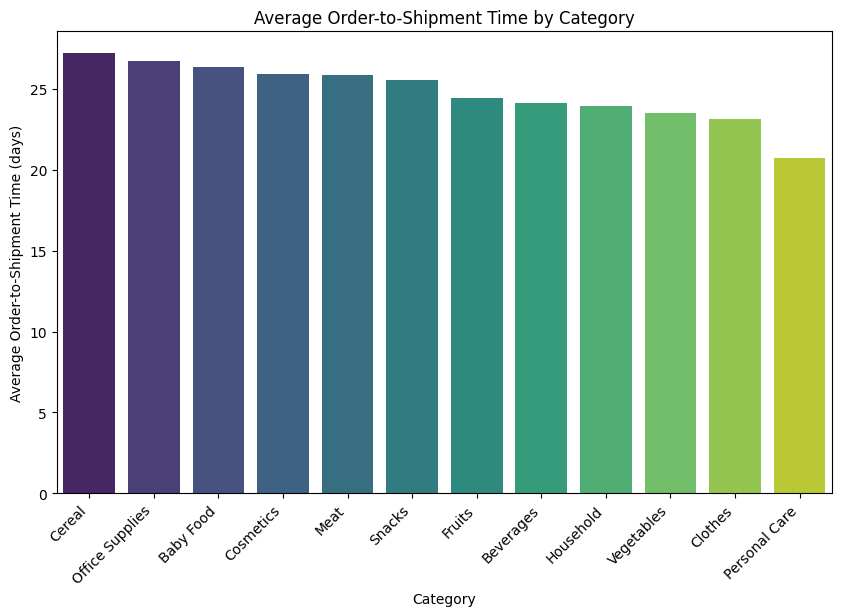

In [ ]:
# Visualizing the average order-to-shipment time by product category

shipping_time_by_category = df.groupby("product_category")["shipping_time"].mean().sort_values(ascending=False).reset_index()

colors = sns.color_palette("viridis", len(shipping_time_by_category))

plt.figure(figsize=(10,6))
sns.barplot(data=shipping_time_by_category, x="product_category", y="shipping_time", palette=colors, errorbar=None)
plt.title("Average Order-to-Shipment Time by Category")
plt.xlabel("Category")
plt.ylabel("Average Order-to-Shipment Time (days)")
plt.xticks(rotation=45, ha="right")
plt.show()

(EN)

***Analysis of the average order-to-shipment time by product category:***

* The longest shipment time is observed in the *Cereal*, *Office Supplies*, and *Baby Food* categories.

* The shortest shipment time is observed in the *Clothes* and *Personal Care* categories.

(PL)

***Analiza średniego czasu od zamówienia do wysyłki według kategorii produktów:***

* Najdłuższy czas wysyłki odnotowano w kategoriach *Cereal*, *Office Supplies* oraz *Baby Food*.

* Najkrótszy czas wysyłki występuje w kategoriach *Clothes* oraz *Personal Care*.



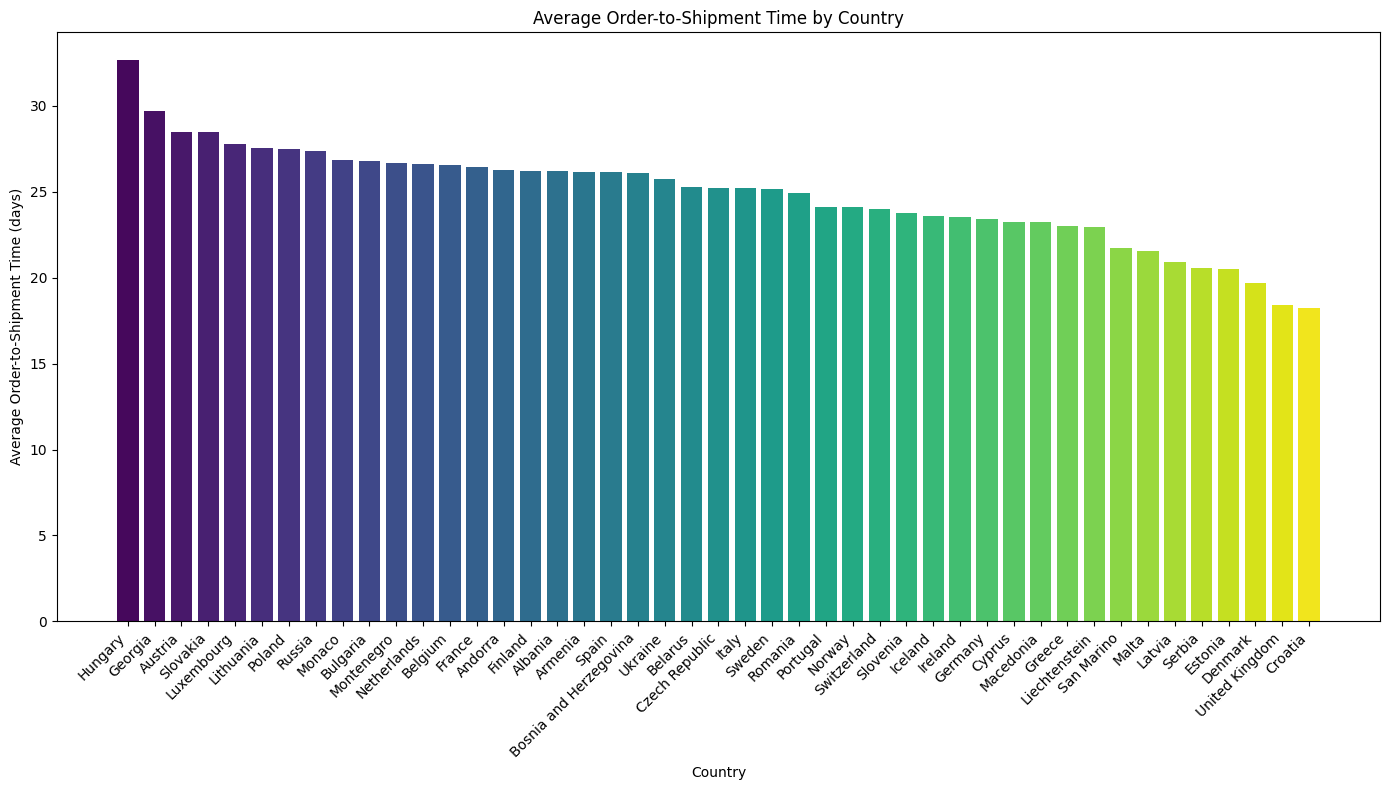

In [ ]:
# Visualizing the average order-to-shipment time by country

shipping_time_by_country = df.groupby("country")["shipping_time"].mean().sort_values(ascending=False)

colors = sns.color_palette("viridis", len(shipping_time_by_country))

plt.figure(figsize=(14,8))
plt.bar(shipping_time_by_country.index, shipping_time_by_country.values, color=colors)
plt.title("Average Order-to-Shipment Time by Country")
plt.xlabel("Country")
plt.ylabel("Average Order-to-Shipment Time (days)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

(EN)

***Average order-to-shipment time by country:***

* The longest shipment time is in *Hungary* (~34 days).

* A slightly shorter but still long shipment time is in *Georgia*, *Austria*, *Slovakia*, and *Luxembourg* (27–29 days).

* The shortest shipment time is in the *United Kingdom* and *Croatia* (~18 days).

* Most countries are in the range of 23–27 days.

***Recommendations:***

* It is worth improving logistics to reduce shipment and delivery time. Even if this does not directly affect profit, faster delivery can improve customer loyalty and become a competitive advantage.

* It may also be useful to increase the number of regional warehouses, since storing goods in one distant central warehouse increases shipment and delivery time.

(PL)

***Średni czas od zamówienia do wysyłki według krajów:***

* Najdłuższy czas wysyłki jest na *Węgrzech* (~34 dni).

* Nieco krótszy, ale nadal długi czas wysyłki jest w *Gruzji*, *Austrii*, *Słowacji* oraz *Luksemburgu* (27–29 dni).

* Najkrótszy czas wysyłki jest w *Wielkiej Brytanii* oraz *Chorwacji* (~18 dni).

* Większość krajów mieści się w przedziale 23–27 dni.

***Rekomendacje:***

* Warto poprawić logistykę, aby skrócić czas wysyłki i dostawy. Nawet jeśli nie wpływa to bezpośrednio na zysk, szybsza dostawa może zwiększyć lojalność klientów i dać przewagę nad konkurencją.

* Można także rozważyć zwiększenie liczby magazynów regionalnych, ponieważ przechowywanie towarów w jednym odległym magazynie wydłuża czas wysyłki i dostawy.

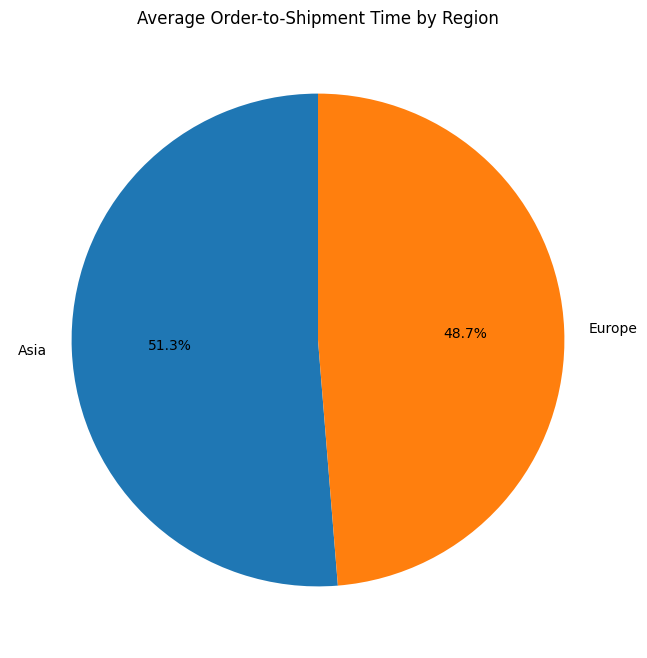

In [ ]:
# Visualizing the average order-to-shipment time by region

shipping_time_by_region = df.groupby("region")["shipping_time"].mean().reset_index()

plt.figure(figsize=(8,8))
plt.pie(shipping_time_by_region["shipping_time"], labels=shipping_time_by_region["region"], autopct="%1.1f%%", startangle=90)
plt.title("Average Order-to-Shipment Time by Region")
plt.show()

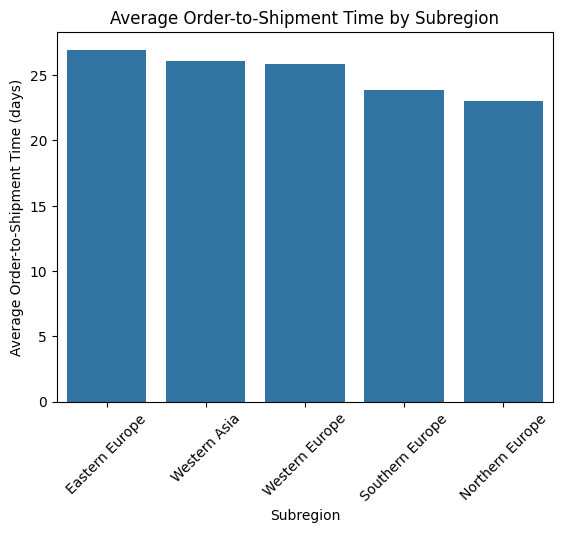

In [ ]:
# Visualizing the average order-to-shipment time by subregion

ship_time_by_subregion = df.groupby("sub_region")["shipping_time"].mean().sort_values(ascending=False).reset_index()

sns.barplot(data=ship_time_by_subregion, x="sub_region", y="shipping_time")
plt.title("Average Order-to-Shipment Time by Subregion")
plt.xlabel("Subregion")
plt.ylabel("Average Order-to-Shipment Time (days)")
plt.xticks(rotation=45)
plt.show()

(EN)

***Average order-to-shipment time by region and subregion:***

* The order-to-shipment time in *Europe* and *Asia* is quite similar, and no large differences are observed.

* The longest order-to-shipment time is in *Eastern Europe*, while the shortest order-to-shipment time is in *Northern Europe*.

(PL)

***Średni czas od zamówienia do wysyłki w podziale na regiony i subregiony:***

* Czas od zamówienia do wysyłki w *Europie* i *Azji* jest dość podobny i nie widać dużych różnic.

* Najdłuższy czas od zamówienia do wysyłki występuje w *Europie Wschodniej*, a najkrótszy w *Europie Północnej*.



## ***`Analysis of profit depending on order-to-shipment time`***

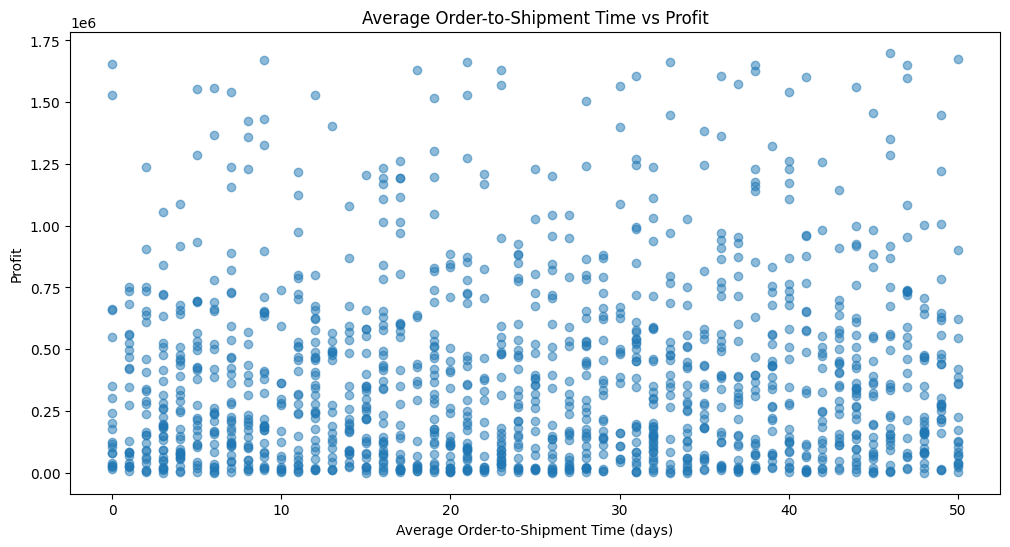

In [ ]:
# Visualizing the impact of average order-to-shipment time on profit

avg_shipping_time = df.groupby("order_id")["shipping_time"].mean()
avg_shipping_time_profit = df.groupby("order_id")["profit"].sum()

plt.figure(figsize=(12,6))
plt.scatter(avg_shipping_time, avg_shipping_time_profit, alpha=0.5)
plt.title("Average Order-to-Shipment Time vs Profit")
plt.xlabel("Average Order-to-Shipment Time (days)")
plt.ylabel("Profit")
plt.show()

(EN)

***Profit and average order-to-shipment time:***

On the chart, the points are spread randomly. There is no clear relationship between profit and order-to-shipment time.

Profit can be high with both short and long shipment times.

This means that profit does not depend on order-to-shipment time. Other factors affect profit, such as *Units Sold*, *Unit Price*, *Product Category*, *Country*, and *Sales Channel*.

(PL)

***Zysk a średni czas od zamówienia do wysyłki:***

Na wykresie punkty są rozmieszczone losowo. Nie ma wyraźnej zależności między zyskiem a czasem od zamówienia do wysyłki.

Zysk może być wysoki zarówno przy krótkim, jak i długim czasie wysyłki.

Oznacza to, że zysk nie zależy od czasu od zamówienia do wysyłki. Na zysk wpływają inne czynniki, takie jak *Units Sold*, *Unit Price*, *Product Category*, *Country* oraz *Sales Channel*.

## ***`Analysis of sales over time`***

In [ ]:
# Total revenue by product category and order date (double aggregation)

time_series_data = df.groupby(["product_category", "order_date"])["revenue"].sum().reset_index()
time_series_data.head()

,product_category,order_date,revenue
0,Baby Food,2010-01-01,2391207.76
1,Baby Food,2010-01-11,1592436.64
2,Baby Food,2010-01-18,165676.72
3,Baby Food,2010-02-10,1272060.24
4,Baby Food,2010-03-16,1744328.24


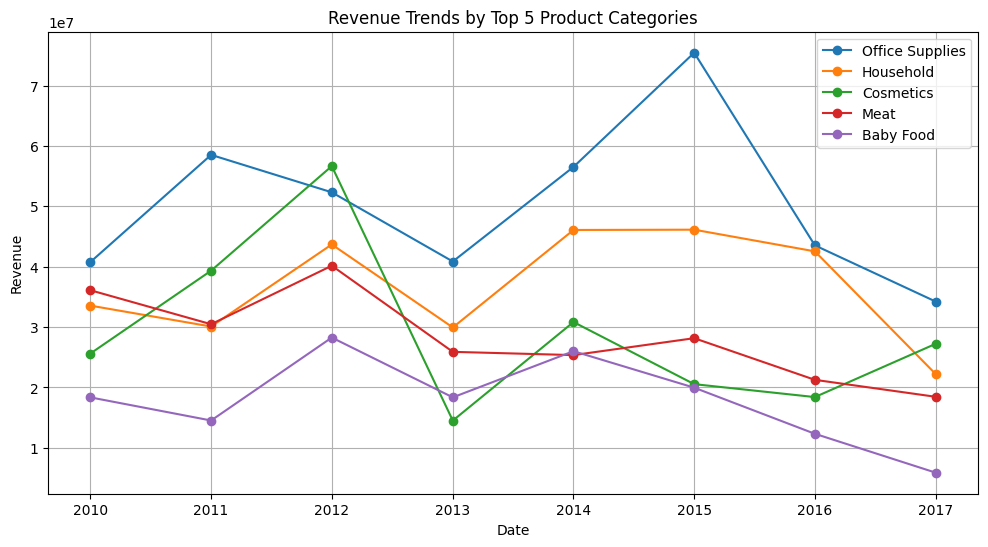

In [ ]:
# Visualizing revenue over time for the top 5 product categories

df["year"] = df["order_date"].dt.to_period("Y").dt.to_timestamp()

time_series_data = (df.groupby(["product_category", "year"])["revenue"].sum().reset_index())

time_series_data = time_series_data.sort_values("year")

product_categories = df.groupby("product_category")["revenue"].sum().sort_values(ascending=False).head(5).index

plt.figure(figsize=(12,6))
for category in product_categories:
  category_data = time_series_data[time_series_data["product_category"] == category]
  plt.plot(category_data["year"], category_data["revenue"], label=category, marker="o")

plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Revenue Trends by Top 5 Product Categories")
plt.legend()
plt.grid(True)
plt.show()

(EN)

***Sales trends for the top 5 product categories:***

* *Office Supplies* is the main source of revenue, so the company should focus on this category.

* *Household* also shows high results, but slightly lower than *Office Supplies*.

* *Baby Food* has stable but the lowest revenue among the top categories. This may mean that it receives less marketing attention. It has growth potential, just like *Cosmetics* and *Meat*.

* There are some periodic increases in demand in different categories. These may be related to holidays, promotions, sales, or large one-time purchases. No clear patterns or seasonality are visible.

(PL)

***Dynamika sprzedaży w top 5 kategoriach produktów:***

* *Office Supplies* jest głównym źródłem dochodu, dlatego firma powinna skupić się na tej kategorii.

* *Household* również ma wysokie wyniki, ale nieco niższe niż *Office Supplies*.

* *Baby Food* ma stabilne, ale najniższe przychody wśród top kategorii. Może to oznaczać mniejszą uwagę marketingową. Ma potencjał wzrostu, podobnie jak *Cosmetics* i *Meat*.

* Widać okresowe wzrosty popytu w różnych kategoriach. Mogą być one związane ze świętami, promocjami, wyprzedażami lub dużymi jednorazowymi zakupami. Nie widać wyraźnej sezonowości ani stałych wzorców.

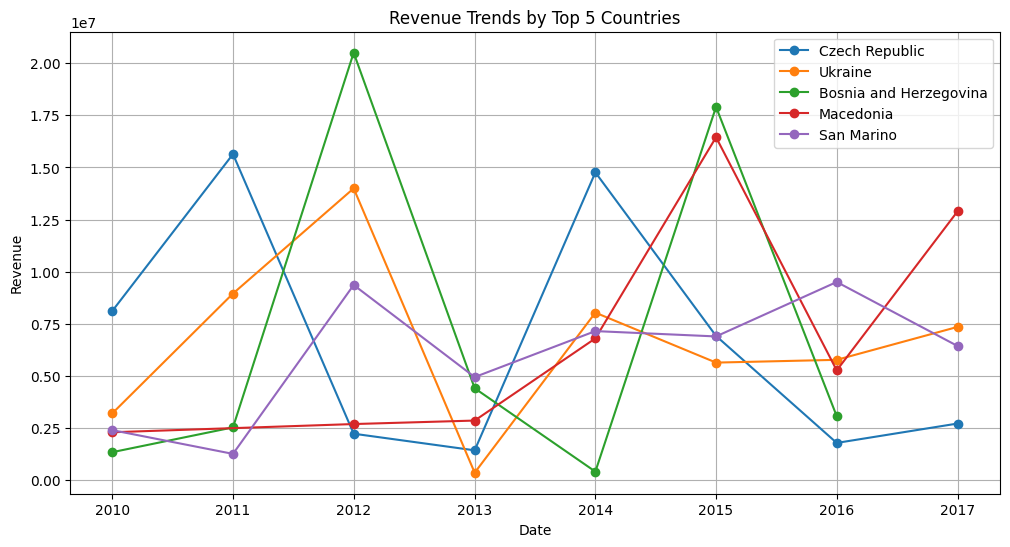

In [ ]:
# Visualizing revenue over time for the top 5 countries

time_series_data = (df.groupby(["country", "year"])["revenue"].sum().reset_index())

time_series_data = time_series_data.sort_values("year")

countries = df.groupby("country")["revenue"].sum().sort_values(ascending=False).head(5).index

plt.figure(figsize=(12,6))
for country in countries:
  country_data = time_series_data[time_series_data["country"] == country]
  plt.plot(country_data["year"], country_data["revenue"], label=country, marker="o")

plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Revenue Trends by Top 5 Countries")
plt.legend()
plt.grid(True)
plt.show()

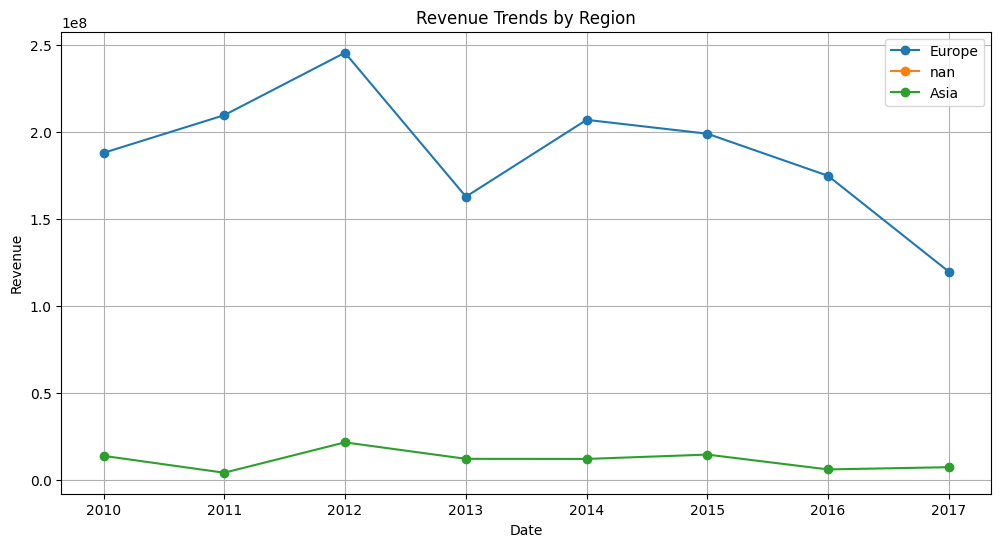

In [ ]:
# Visualizing revenue over time by region

time_series_data = (df.groupby(["region", "year"])["revenue"].sum().reset_index())

time_series_data = time_series_data.sort_values("year")

regions = df["region"].unique()

plt.figure(figsize=(12,6))
for region in regions:
  region_data = time_series_data[time_series_data["region"] == region]
  plt.plot(region_data["year"], region_data["revenue"], label=region, marker="o")

plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Revenue Trends by Region")
plt.legend()
plt.grid(True)
plt.show()

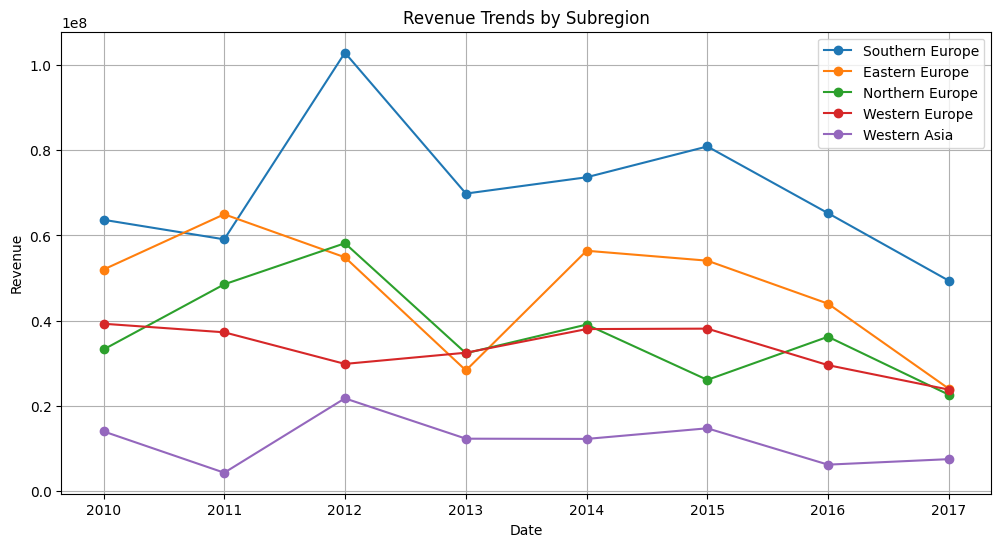

In [ ]:
# Visualizing revenue over time by subregion

time_series_data = (df.groupby(["sub_region", "year"])["revenue"].sum().reset_index())

time_series_data = time_series_data.sort_values("year")

sub_regions = df.groupby("sub_region")["revenue"].sum().sort_values(ascending=False).index

plt.figure(figsize=(12,6))
for sub_region in sub_regions:
  sub_region_data = time_series_data[time_series_data["sub_region"] == sub_region]
  plt.plot(sub_region_data["year"], sub_region_data["revenue"], label=sub_region, marker="o")

plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Revenue Trends by Subregion")
plt.legend()
plt.grid(True)
plt.show()

(EN)

***Sales trends by geography:***

* Sales started to decrease after 2012. This may be due to stronger competition, economic problems, or lower demand.

* The company should focus more on Europe, especially Eastern, Western, and Northern Europe, to make sales more stable in all subregions. Now, most sales come from Southern Europe.

* It is a good idea to introduce loyalty programs and add new products to keep customers interested.

* Sales in Asia are low but stable. The company can try to grow in this region. It is important to study local needs and adjust products to increase sales and revenue.

(PL)

***Sprzedaż według regionów:***

* Sprzedaż zaczęła spadać po 2012 roku. Może to być spowodowane większą konkurencją, problemami gospodarczymi lub mniejszym popytem.

* Firma powinna bardziej skupić się na Europie, szczególnie na Europie Wschodniej, Zachodniej i Północnej, aby sprzedaż była bardziej stabilna we wszystkich subregionach. Obecnie większość sprzedaży pochodzi z Europy Południowej.

* Warto wprowadzić programy lojalnościowe i dodać nowe produkty, aby utrzymać zainteresowanie klientów.

* Sprzedaż w Azji jest niska, ale stabilna. Firma może spróbować rozwijać się w tym regionie. Ważne jest zbadanie lokalnych potrzeb i dostosowanie produktów, aby zwiększyć sprzedaż i dochód.

## ***`Analysis of product sales by day of the week and season`***



/tmp/ipython-input-544/2065577694.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



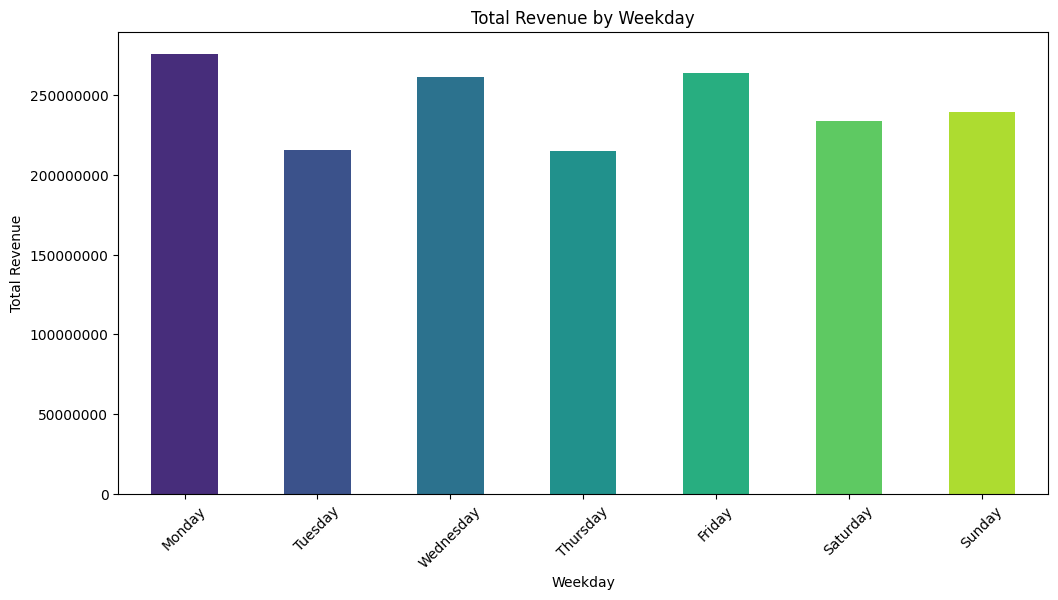

In [ ]:
# Visualizing total revenue by weekday

df['day'] = df['order_date'].dt.day_name()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
colors = sns.color_palette("viridis", n_colors=len(weekday_order))

df["day"] = pd.Categorical(df["day"], categories=weekday_order, ordered=True)

sales_by_day = df.groupby("day")["revenue"].sum()

sales_by_day.plot(kind="bar", color=colors, figsize=(12,6))
plt.title("Total Revenue by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.show()


(EN)

***Analysis of total revenue by day of the week:***

* *Monday* generates the highest revenue, which shows high activity at the beginning of the week.

* There is a drop in revenue on *Tuesday* and *Thursday*, but sales increase again on *Friday*, possibly because customers prepare for the weekend.

* On *Saturday* and *Sunday*, sales decrease slightly but remain stable.

***Recommendations:***

* The company should try to increase sales during the week and on weekends by offering discounts, loyalty programs, and special offers.

* It is also important to maintain high sales on Monday, Wednesday, and Friday. The company should analyze which products are most popular on these days to manage inventory better.

(PL)

***Analiza całkowitego dochodu według dni tygodnia:***

* *Poniedziałek* generuje najwyższy dochód, co pokazuje wysoką aktywność na początku tygodnia.

* We *wtorek* i *czwartek* widać spadek sprzedaży, ale w *piątek* sprzedaż ponownie rośnie, prawdopodobnie z powodu przygotowań do weekendu.

* W *sobotę* i *niedzielę* sprzedaż lekko spada, ale pozostaje stabilna.

***Rekomendacje:***

* Firma powinna zwiększyć sprzedaż w ciągu tygodnia i w weekendy poprzez rabaty, programy lojalnościowe i specjalne oferty.

* Ważne jest także utrzymanie wysokiej sprzedaży w poniedziałek, środę i piątek. Warto sprawdzić, które produkty sprzedają się najlepiej w te dni, aby lepiej zarządzać zapasami.





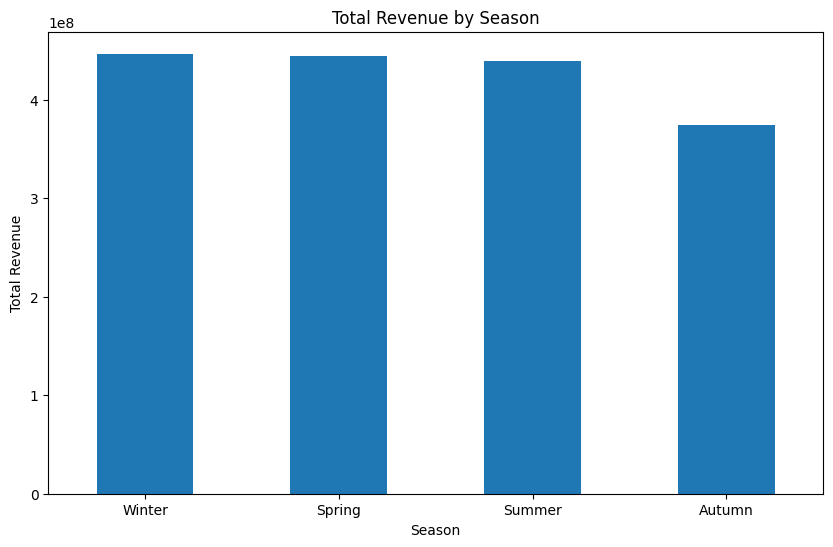

In [ ]:
# Visualizing total revenue by season

season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"}

df["season"] = df["order_date"].dt.month.map(season_map)

sales_by_season = df.groupby("season")["revenue"].sum().sort_values(ascending=False)
sales_by_season.plot(kind="bar", figsize=(10,6))
plt.title("Total Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.show()

(EN)

***Analysis of total revenue by season:***

* Revenue is stable in *winter*, *spring*, and *summer*. This means sales are balanced during most of the year.

* In *autumn*, sales decrease slightly. This may be related to the end of the holiday season.

***Recommendations:***

* The company can expand its product range with items suitable for autumn.

* It is also a good idea to increase customer interest through personalized offers, loyalty programs, and seasonal promotions.

(PL)

***Analiza całkowitego dochodu według sezonów:***

* Dochód jest stabilny *zimą*, *wiosną* i *latem*. Oznacza to, że sprzedaż jest wyrównana przez większość roku.

* *Jesienią* sprzedaż lekko spada. Może to być związane z końcem sezonu wakacyjnego.

***Rekomendacje:***

* Firma może poszerzyć ofertę o produkty odpowiednie na sezon jesienny.

* Warto także zwiększyć zainteresowanie klientów poprzez spersonalizowane oferty, programy lojalnościowe i promocje sezonowe.



